In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy

import time

# !pip install vitaldb
import vitaldb as v

In [3]:
track_names = ["SNUADC/ART",        # Arterial pressure wave  | W/500 | mmHg
               "SNUADC/ECG_II",     # ECG lead II wave        | W/500 | mV
               "SNUADC/ECG_V5",     # ECG lead V5 wave        | W/500 | mV
               "BIS/EEG1_WAV",      # EEG wave from channel 1 | W/128 | uV
               "BIS/EEG2_WAV",      # EEG wave from channel 2 | W/128 | uV
               "Solar8000/RR_CO2",  # Respiratory rate based on capnography | N | /min
               "Primus/CO2",        # Capnography wave        | W/62.5 | mmHg
               "BIS/BIS",           # Bispectral index value  |    N   | unitless
               ]
vf1 = v.VitalFile(1, track_names)
patient1 = vf1.to_pandas(track_names, 5)

# patient1.dropna(subset=["BIS/EEG1_WAV", "BIS/EEG2_WAV"], inplace=True) # no all-NaN cols

      SNUADC/ART  SNUADC/ECG_II  SNUADC/ECG_V5  BIS/EEG1_WAV  BIS/EEG2_WAV  \
0            NaN            NaN            NaN     22.850000     24.700001   
1       -7.82223       0.267388       0.267388     23.700001     23.650000   
2       -7.82223       3.891360       0.158767     22.750000     24.299999   
3       -8.80968       5.145430       0.178517     23.500000     23.799999   
4       -7.82223      -0.088097       0.316761     23.250000     24.750000   
...          ...            ...            ...           ...           ...   
2304     1.06489       0.395757       0.385883     11.550000     30.000000   
2305   -10.78460       0.464879       0.445130      9.400000     30.250000   
2306    -1.89748       0.425381       0.415506     12.500000     30.049999   
2307   -12.75950       0.405632       0.415506     15.400000     31.750000   
2308    12.91440       0.237764       0.218015           NaN           NaN   

      Solar8000/RR_CO2  Primus/CO2  BIS/BIS  
0                

### Read multiple patients into a list (Online Database?)

In [4]:
NUMBER_OF_PATIENTS = 10
patients = []

for i in range(1, NUMBER_OF_PATIENTS+1):
    vf1 = v.VitalFile(i, track_names)
    patients.append(vf1.to_pandas(track_names, 5))



In [5]:
patient1 = patients[0]

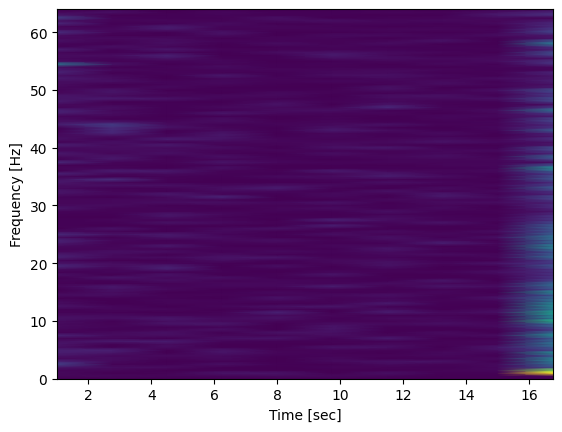

In [7]:
x = patient1["BIS/EEG1_WAV"]
fs = 128

f, t, Sxx = scipy.signal.spectrogram(x, fs)
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

In [8]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

patient1 = vf1.to_pandas(track_names, 1/128) # full time-series

# 1. Clean the signal
# VitalDB waveforms often have NaNs at the start/end of a case
x = patient1["BIS/EEG1_WAV"].dropna().values 
fs = 128

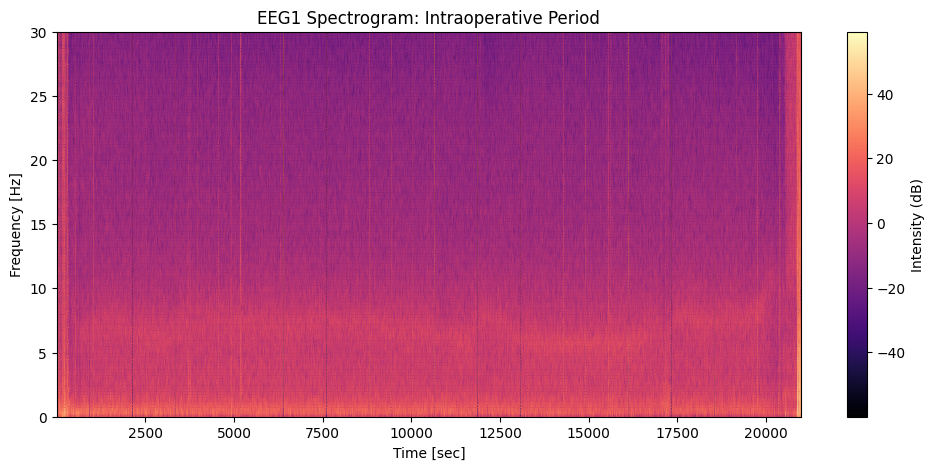

In [9]:
# 2. Compute the Spectrogram
# Use a Hanning window and a 4-second window (512 samples) for better frequency resolution
f, t, Sxx = scipy.signal.spectrogram(x, fs, nperseg=512, noverlap=256, window='hann')

# 3. TRANSFORMATION: Power to Decibels (dB)
# Without this, you won't see the Alpha band (8-12Hz)
Sxx_db = 10 * np.log10(Sxx + 1e-6) 

# 4. Plotting
plt.figure(figsize=(12, 5))

# 'magma' or 'jet' are the industry standards for EEG
plt.pcolormesh(t, f, Sxx_db, shading='gouraud', cmap='magma')

# 5. FOCUS: Most anesthesia-related EEG activity is under 30Hz
plt.ylim(0, 30) 

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('EEG1 Spectrogram: Intraoperative Period')
plt.colorbar(label='Intensity (dB)')
plt.show()

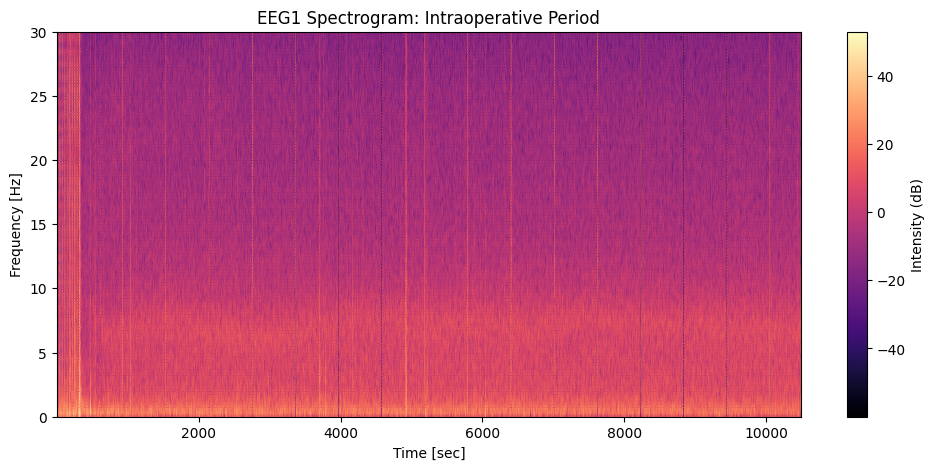

In [10]:
half_point = len(x)//2
x = x[0:half_point]

# 2. Compute the Spectrogram
# Use a Hanning window and a 4-second window (512 samples) for better frequency resolution
f, t, Sxx = scipy.signal.spectrogram(x, fs, nperseg=512, noverlap=256, window='hann')

# 3. TRANSFORMATION: Power to Decibels (dB)
# Without this, you won't see the Alpha band (8-12Hz)
Sxx_db = 10 * np.log10(Sxx + 1e-6) 

# 4. Plotting
plt.figure(figsize=(12, 5))

# 'magma' or 'jet' are the industry standards for EEG
plt.pcolormesh(t, f, Sxx_db, shading='gouraud', cmap='magma')

# 5. FOCUS: Most anesthesia-related EEG activity is under 30Hz
plt.ylim(0, 30) 

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('EEG1 Spectrogram: Intraoperative Period')
plt.colorbar(label='Intensity (dB)')
plt.show()

### both EEG channels

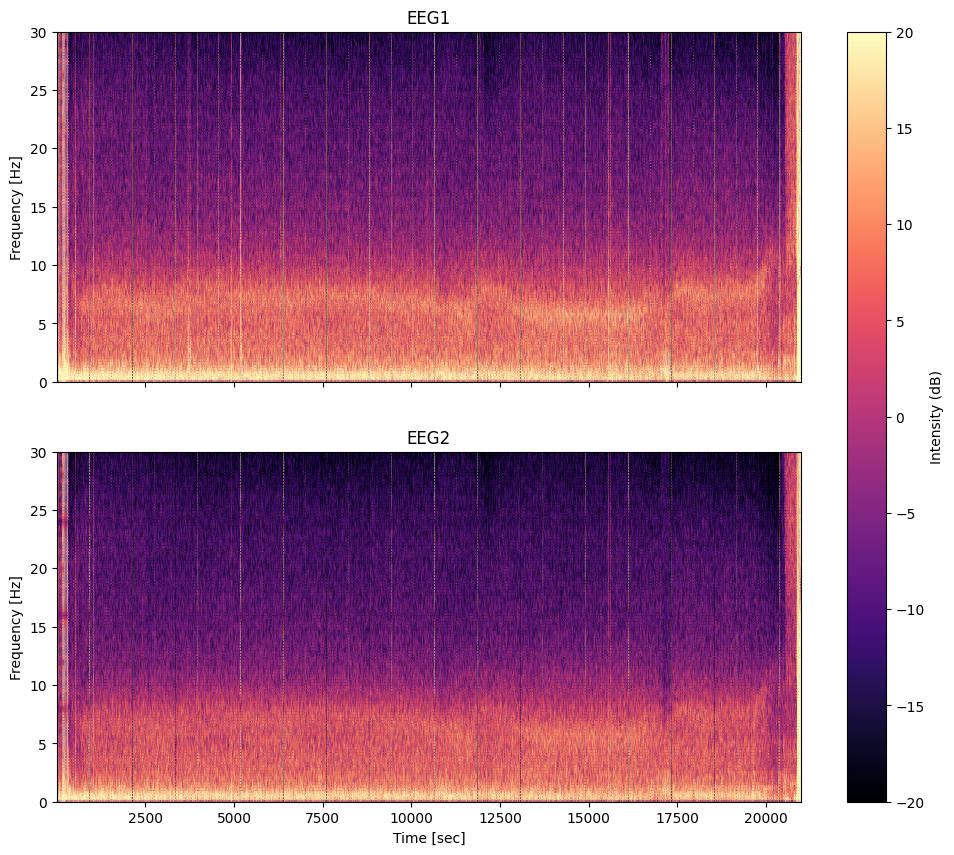

In [11]:
# 1. Load your two tracks (e.g., EEG1 and EEG2)
eeg_1 = patient1["BIS/EEG1_WAV"].dropna().values
eeg_2 = patient1["BIS/EEG2_WAV"].dropna().values
fs = 128

# 2. Setup the Plotting Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

def plot_spec(data, ax, title):
    f, t, Sxx = scipy.signal.spectrogram(data, fs, nperseg=512, noverlap=256)
    Sxx_db = 10 * np.log10(Sxx + 1e-6)
    
    # Plotting
    im = ax.pcolormesh(t, f, Sxx_db, shading='gouraud', cmap='magma', vmin=-20, vmax=20)
    ax.set_ylim(0, 30) # Focus on 0-30Hz
    ax.set_ylabel('Frequency [Hz]')
    ax.set_title(title)
    return im

# 3. Generate both plots
im1 = plot_spec(eeg_1, ax1, "EEG1")
im2 = plot_spec(eeg_2, ax2, "EEG2")

plt.xlabel('Time [sec]')
fig.colorbar(im2, ax=[ax1, ax2], label='Intensity (dB)')
plt.show()

5,566 (87.1%) cases recorded with BIS Vista